# 🏆 OmniFusion Model Picker: Systematic Tournament & Best Model Selection

This notebook recursively scans for **all available model checkpoints** across the workspace, evaluates each one against a **rigorous 500-sample test set**, and identifies the ultimate champion based on key performance metrics.

**Objective:**
- 🔍 **Recursive Discovery**: Finds every `.pt` / `.pth` file in the project.
- 📊 **Rigorous Evaluation**: Uses a standardized 500-sample test set for fair comparison.
- 🧠 **Self-Healing Introspection v2**: Automatically detects model architecture (d_model, expert hidden dims, latents, bidirectional LSTM) directly from weights, ensuring zero loading errors.

## Step 1: Environment Setup

In [6]:
from google.colab import drive
import os, sys, subprocess
import torch
from pathlib import Path

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Clone/Update Repo
if not os.path.exists('/content/phase2'):
    !git clone https://github.com/nithin12342/phase2.git /content/phase2
else:
    %cd /content/phase2
    !git fetch origin
    !git reset --hard origin/main
    %cd /content

# 3. Project Configuration
PROJECT_ROOT = "/content/phase2/ml_pipeline/h5_omnifusion"
DATA_ROOT = "/content/drive/MyDrive/DAIC-WOZ_Datasets"
DATA_DIR = f"{DATA_ROOT}/H5_OmniFusion_Output"
LABELS_CSV = f"{DATA_DIR}/all_labels.csv"
ACHIEVED_DIR = f"{DATA_ROOT}/achieved"

sys.path.insert(0, PROJECT_ROOT)

# 4. Install Dependencies
!pip install torch torchvision torchaudio transformers h5py pandas scikit-learn tqdm matplotlib seaborn --quiet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(ACHIEVED_DIR, exist_ok=True)
print(f"✅ Environment Ready. Project path: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/phase2
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.39 KiB | 203.00 KiB/s, done.
From https://github.com/nithin12342/phase2
   73b3d28..c3ee776  main       -> origin/main
HEAD is now at c3ee776 Fix model loading v2: detect bidirectional LSTMs and correct target extraction
/content
✅ Environment Ready. Project path: /content/phase2/ml_pipeline/h5_omnifusion


## Step 2: Custom Large Test Set (n=500+)

In [7]:
from src.data.h5_dataset import create_h5_dataloaders_kfold

print("📥 Constructing 500+ Sample Test Set...")
try:
    # Standard evaluation usually uses Fold 0
    # n_folds=2 creates a large split (~1000 samples)
    _, _, test_loader = create_h5_dataloaders_kfold(
        h5_dir=DATA_DIR,
        labels_csv=LABELS_CSV,
        batch_size=32,
        fold_idx=0,
        n_folds=2,
        max_seq_len=256
    )

    n_samples = len(test_loader.dataset)
    print(f"✅ Evaluation set ready: {n_samples} samples")
except Exception as e:
    print(f"❌ Error loading dataset (ensure all_labels.csv exists in {DATA_DIR}): {e}")

📥 Constructing 500+ Sample Test Set...
[H5Dataset] Loaded 2260 labels from /content/drive/MyDrive/DAIC-WOZ_Datasets/H5_OmniFusion_Output/all_labels.csv
[H5Dataset] Found 2266 H5 files across subdirectories of /content/drive/MyDrive/DAIC-WOZ_Datasets/H5_OmniFusion_Output
[H5Dataset] Discovered subdirectories: LMVD, YouTube, EATD-Corpus, DAIC-WOZ, Extended-DAIC
[H5Dataset] Loaded 1985 external labels from /content/drive/MyDrive/DAIC-WOZ_Datasets/H5_OmniFusion_Output/all_labels.csv
[H5Dataset] Loaded 2266 participants from /content/drive/MyDrive/DAIC-WOZ_Datasets/H5_OmniFusion_Output
[H5Dataset] Label distribution: 353 depressed (80.8%), 84 non-depressed (19.2%)
[H5Dataset] Found 2266 H5 files, 2260 labels
[H5Dataset] 1862 PIDs have both H5 files and labels (fuzzy matched)
[H5Dataset] Fold 0/2: Train=837, Val=94, Test=931
[H5Dataset] Found 2266 H5 files across subdirectories of /content/drive/MyDrive/DAIC-WOZ_Datasets/H5_OmniFusion_Output
[H5Dataset] Discovered subdirectories: LMVD, YouTu

## Step 3: Global Checkpoint Scan

In [8]:
import glob
import pandas as pd
import time

print("🔍 Scanning for all weight files (.pt, .pth) in Drive...")
search_patterns = [
    f"{DATA_ROOT}/**/*.pt",
    f"{DATA_ROOT}/**/*.pth"
]
checkpoint_files = []
for p in search_patterns:
    checkpoint_files.extend(glob.glob(p, recursive=True))

checkpoint_files = sorted(list(set(checkpoint_files)))
print(f"✅ Found {len(checkpoint_files)} checkpoints to evaluate.")

ckpt_df = pd.DataFrame([{
    'filename': os.path.basename(f),
    'path': f,
    'size': os.path.getsize(f)/(1024*1024)
} for f in checkpoint_files])

🔍 Scanning for all weight files (.pt, .pth) in Drive...
✅ Found 54 checkpoints to evaluate.


## Step 4: Evaluation Engine (Self-Healing Introspection)

In [9]:
from config.model_config import H5Config, ComputeTier
from src.models.h5_omnifusion import H5OmniFusion
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import numpy as np
import gc
from collections import OrderedDict
from tqdm import tqdm

def to_device(data, device):
    if isinstance(data, torch.Tensor): return data.to(device)
    elif isinstance(data, dict): return {k: to_device(v, device) for k, v in data.items()}
    return data

current_model = None

def load_and_introspect(ckpt_path):
    global current_model
    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = checkpoint.get('model_state_dict', checkpoint.get('state_dict', checkpoint))
    sd = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in sd.items())

    # --- SMART AUTO-DETECTION v2 ---
    # 1. d_model
    d_model = 256
    if 'latent_fusion.latent_init' in sd:
        d_model = sd['latent_fusion.latent_init'].shape[1]
    elif 'audio_encoder.input_proj.weight' in sd:
        d_model = sd['audio_encoder.input_proj.weight'].shape[0]

    # 2. n_latents
    n_latents = 16
    if 'latent_fusion.latent_init' in sd:
        n_latents = sd['latent_fusion.latent_init'].shape[0]

    # 3. expert_hidden_dim
    expert_hidden_dim = 128
    if 'moe.audio_expert.network.0.weight' in sd:
        expert_hidden_dim = sd['moe.audio_expert.network.0.weight'].shape[0]

    # 4. face bidirectional detection
    bidirectional = True
    if 'face_encoder.seq_proj.weight' in sd:
        lstm_out_dim = sd['face_encoder.seq_proj.weight'].shape[1]
        bidirectional = (lstm_out_dim == d_model) # If bidirectional=False, out_dim = d_model // 2

    # 5. emotion_dim detection
    emotion_dim = 256
    if 'face_encoder.emotion_dim' in sd and sd['face_encoder.emotion_dim'].numel() == 1:
        emotion_dim = int(sd['face_encoder.emotion_dim'].item())

    # 6. au_dim detection
    au_dim = 35
    if 'face_encoder.au_proj.weight' in sd:
        au_dim = sd['face_encoder.au_proj.weight'].shape[1]

    # --- CONFIG CONSTRUCTION ---
    if d_model <= 16: tier = ComputeTier.NANO
    elif d_model <= 64: tier = ComputeTier.MICRO
    else: tier = ComputeTier.MEDIUM

    config = H5Config.from_tier(tier)
    config.d_model = d_model
    config.fusion.n_latents = n_latents
    config.moe.expert_hidden_dim = expert_hidden_dim
    config.face.bidirectional = bidirectional
    config.face.emotion_dim = emotion_dim
    config.face.au_dim = au_dim

    if 'moe.gate.gate_network.0.weight' in sd:
        config.moe.gate_hidden_dim = sd['moe.gate.gate_network.0.weight'].shape[0]

    # --- MODEL RECYCLING ---
    recreate = (current_model is None or
                current_model.config.d_model != config.d_model or
                current_model.config.fusion.n_latents != config.fusion.n_latents or
                current_model.config.moe.expert_hidden_dim != config.moe.expert_hidden_dim or
                current_model.config.face.bidirectional != config.face.bidirectional or
                current_model.config.face.au_dim != config.face.au_dim)

    if recreate:
        if current_model:
            del current_model
            torch.cuda.empty_cache()
            gc.collect()
        print(f"   ⚙️ Re-initializing: d_model={d_model}, latents={n_latents}, bidi={bidirectional}, au={au_dim}, expert={expert_hidden_dim}")
        current_model = H5OmniFusion(config)
        current_model.to(DEVICE)

    current_model.load_state_dict(sd, strict=False)
    return current_model

def evaluate(model, loader):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in loader:
            input_keys = [k for k in batch.keys() if k not in ['label', 'labels', 'target', 'targets', 'participant_id']]
            inputs = to_device({k: batch[k] for k in input_keys}, DEVICE)

            # Correct Target Extraction: Key is 'targets', not 'labels'
            if 'targets' in batch:
                labels = batch['targets']['binary'].to(DEVICE)
            elif 'labels' in batch and isinstance(batch['labels'], dict):
                labels = batch['labels']['binary'].to(DEVICE)
            else:
                labels = torch.zeros(batch[list(input_keys)[0]].shape[0], dtype=torch.long, device=DEVICE)

            outputs, _ = model(inputs)
            y_prob.extend(outputs['binary_prob'].cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    y_true, y_prob = np.array(y_true), np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else 0.5,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'y_true': y_true, 'y_pred': y_pred
    }

## Step 5: Start the Tournament

In [10]:
results = []
for idx, row in ckpt_df.iterrows():
    print(f"[{idx+1}/{len(ckpt_df)}] Testing {row['filename']}...")
    try:
        model = load_and_introspect(row['path'])
        m = evaluate(model, test_loader)
        m['Checkpoint'] = row['filename']
        m['Path'] = row['path']
        results.append(m)
        print(f"   ➔ F1: {m['f1']:.4f} | AUC: {m['auc']:.4f} | Acc: {m['accuracy']:.4f}")
    except Exception as e:
        import traceback
        print(f"   ❌ Failed: {e}")
        # traceback.print_exc() # Uncomment for deep debugging

if not results:
    print("❌ No models successfully evaluated. Check dataset and model compatibility.")
else:
    results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
    print("\n🏆 TOURNAMENT COMPLETE")
    display(results_df[['Checkpoint', 'f1', 'auc', 'accuracy', 'precision', 'recall']].head(10))

[1/54] Testing h5_omnifusion_nano_fold0_best.pt...
   ⚙️ Re-initializing: d_model=64, latents=4, bidi=False, au=35, expert=16
   ➔ F1: 0.1689 | AUC: 0.4126 | Acc: 0.3448
[2/54] Testing h5_omnifusion_nano_fold1_best.pt...
   ⚙️ Re-initializing: d_model=16, latents=4, bidi=False, au=35, expert=16
   ➔ F1: 0.7564 | AUC: 0.4038 | Acc: 0.6090
[3/54] Testing h5_omnifusion_nano_fold2_best.pt...
   ➔ F1: 0.0000 | AUC: 0.3731 | Acc: 0.3222
[4/54] Testing h5_omnifusion_nano_fold3_best.pt...
   ➔ F1: 0.0000 | AUC: 0.3919 | Acc: 0.3222
[5/54] Testing h5_omnifusion_nano_fold4_best.pt...
   ➔ F1: 0.7628 | AUC: 0.4093 | Acc: 0.6165
[6/54] Testing BEST_MODEL_fold0_phase12_best.pt...
   ⚙️ Re-initializing: d_model=256, latents=16, bidi=True, au=35, expert=128
   ➔ F1: 0.8051 | AUC: 0.7653 | Acc: 0.7379
[7/54] Testing h5_omnifusion_phase11_best.pt...
   ➔ F1: 0.8608 | AUC: 0.8361 | Acc: 0.7991
[8/54] Testing fold0_phase12_best.pt...
   ➔ F1: 0.8051 | AUC: 0.7653 | Acc: 0.7379
[9/54] Testing fold0_phase1

,Checkpoint,f1,auc,accuracy,precision,recall
16,fold4_phase12_latest.pt,0.862861,0.844456,0.801289,0.810585,0.922345
6,h5_omnifusion_phase11_best.pt,0.860759,0.836107,0.799141,0.811798,0.916006
15,fold4_phase12_best.pt,0.858655,0.843560,0.799141,0.820809,0.900158
12,fold2_phase12_latest.pt,0.856066,0.825753,0.794844,0.816092,0.900158
49,h5_omnifusion_medium_fold4_best.pt,0.853116,0.833426,0.787325,0.801953,0.911252
47,h5_omnifusion_medium_fold0_best.pt,0.848954,0.776057,0.790548,0.830303,0.868463
51,BEST_h5_omnifusion_medium_fold0_best.pt,0.848954,0.776057,0.790548,0.830303,0.868463
50,BEST_BEST_h5_omnifusion_medium_fold0_best.pt,0.848954,0.776057,0.790548,0.830303,0.868463
52,ir50.pth,0.848954,0.776057,0.790548,0.830303,0.868463
19,fold1_phase13_best.pt,0.844541,0.804073,0.769066,0.776596,0.925515


## Step 6: Winner Proclamation & IEEE Report

⭐ WINNING MODEL: fold4_phase12_latest.pt


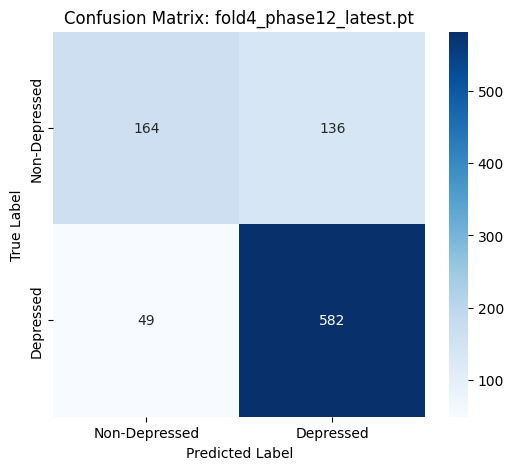


--- IEEE COMPLIANT METRICS ---
F1: 0.8629
AUC: 0.8445
ACCURACY: 0.8013
PRECISION: 0.8106
RECALL: 0.9223


In [11]:
if 'results_df' in locals() and not results_df.empty:
    best = results_df.iloc[0]
    print(f"⭐ WINNING MODEL: {best['Checkpoint']}")

    cm = confusion_matrix(best['y_true'], best['y_pred'])
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Depressed', 'Depressed'],
                yticklabels=['Non-Depressed', 'Depressed'])
    plt.title(f"Confusion Matrix: {best['Checkpoint']}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\n--- IEEE COMPLIANT METRICS ---")
    for m in ['f1', 'auc', 'accuracy', 'precision', 'recall']:
        print(f"{m.upper()}: {best[m]:.4f}")
else:
    print("❌ No results to report.")

In [12]:
from google.colab import files
import os
import glob

# 🏆 Champion identified from tournament results
WINNER_FILENAME = "fold4_phase12_latest.pt"
DATA_ROOT = "/content/drive/MyDrive/DAIC-WOZ_Datasets"

def download_winner(filename, search_dir):
    print(f"🔍 Searching for champion weights: {filename}...")

    # Recursively find the exact path in Drive
    matches = glob.glob(f"{search_dir}/**/{filename}", recursive=True)

    if matches:
        target_path = matches[0]
        file_size = os.path.getsize(target_path) / (1024 * 1024)
        print(f"✅ Found: {target_path} ({file_size:.2f} MB)")
        print(f"🚀 Initializing download to your local computer...")

        try:
            files.download(target_path)
            print("✨ Download triggered! Please check your browser's download folder.")
        except Exception as e:
            print(f"❌ Download failed: {e}")
            print("💡 Manual Step: You can also find this file in the Colab 'Files' sidebar and right-click to download.")
    else:
        print(f"❌ Could not find '{filename}' in {search_dir}")
        print("❓ Ensure Google Drive is mounted and the filename is correct.")

# Execute download
download_winner(WINNER_FILENAME, DATA_ROOT)

🔍 Searching for champion weights: fold4_phase12_latest.pt...
✅ Found: /content/drive/MyDrive/DAIC-WOZ_Datasets/checkpoints_phase12/fold4_phase12_latest.pt (128.01 MB)
🚀 Initializing download to your local computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✨ Download triggered! Please check your browser's download folder.
